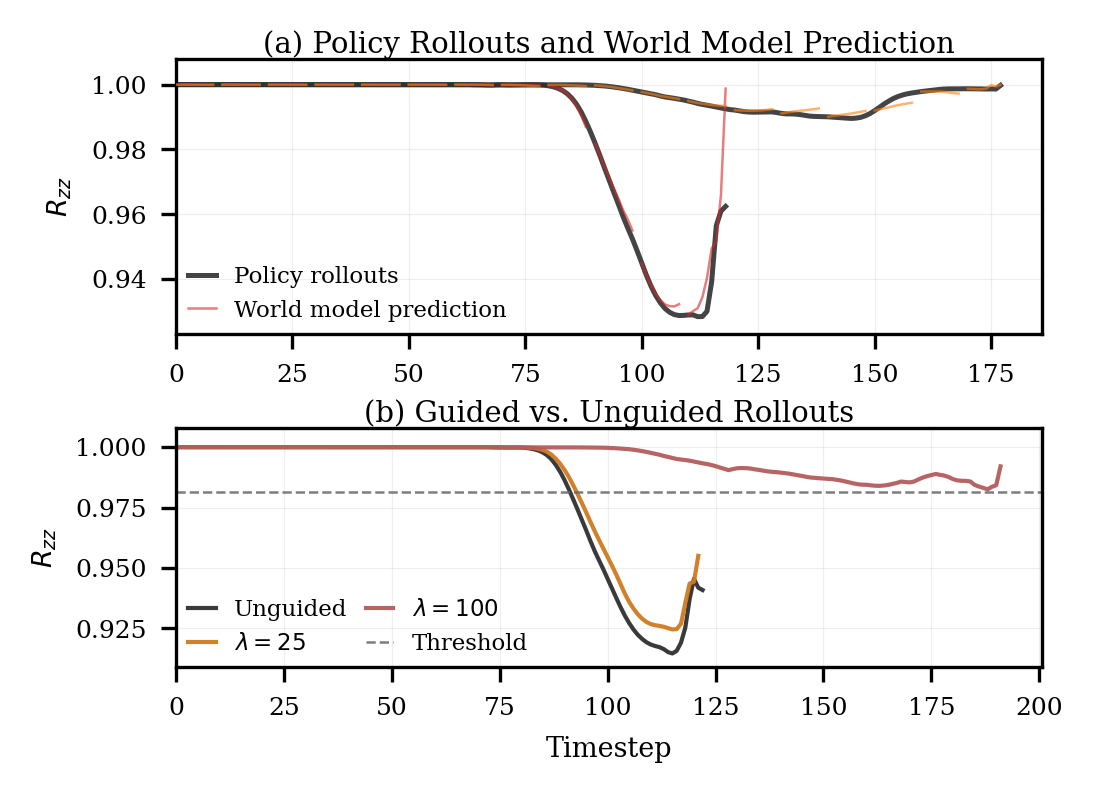

Saved PNG to: ../outputs/guidance_artifacts/seeded_guided_diffusion_seed_3/paper_two_panel_diffusion_and_guidance.png
Saved PDF to: ../outputs/guidance_artifacts/seeded_guided_diffusion_seed_3/paper_two_panel_diffusion_and_guidance.pdf
Figure size in inches: [3.5 2.5]


In [58]:
from pathlib import Path
import pickle
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make local guidance utilities importable from the figures/ notebook directory
sys.path.append(str((Path("..") / "guidance").resolve()))
from world_model_utils import (
    load_model_for_eval,
    rzz_from_state_29d,
    predict_next_state_from_raw,
 )

# -----------------------------
# Shared paper-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.labelsize": 6.5,
    "axes.titlesize": 7,
    "axes.titleweight": "normal",
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 5.5,
})

# -----------------------------
# Load data for (a) Diffusion Policy Behavior
# -----------------------------
run_dir = Path("../outputs/can_rollouts/diffusion_guidance_checks/20260404_135244")
rollout_pkl = run_dir / "seed_rollouts_full.pkl"
with open(rollout_pkl, "rb") as f:
    seed_rollouts = pickle.load(f)

all_trajs = []
for seed_name in sorted(seed_rollouts.keys()):
    for rep_idx, rollout in enumerate(seed_rollouts[seed_name], start=1):
        all_trajs.append((seed_name, rep_idx, rollout))
selected_trajs = all_trajs[:2]

device = "cuda" if __import__("torch").cuda.is_available() else "cpu"
predictor, stats, _, eval_meta = load_model_for_eval(
    model_or_run_path="../models/dynamics/baseline_mlp",
    predictor_kind="learned",
    device=device,
    load_val_trajectories=False,
 )

# -----------------------------
# Load data for (b) Guidance Scale
# -----------------------------
artifact_root = Path("../outputs/guidance_artifacts/seeded_guided_diffusion_seed_3")
scales_to_plot = [0, 25, 100]
label_map = {0: "Unguided", 25: r"$\lambda = 25$", 100: r"$\lambda = 100$"}
# Muted warm palette (distinct from world-model branch colors)
color_map = {0: "#2f2f2f", 25: "#d07a1f", 100: "#b35c5c"}

rzz_series = {}
for s in scales_to_plot:
    npz_path = artifact_root / f"scale_{s}_seed_3" / "rollout_numeric.npz"
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing rollout file: {npz_path}")
    data = np.load(npz_path)
    rzz_series[s] = np.asarray(data["rzz_mujoco"], dtype=np.float32)

# Threshold for the second subplot
thrsh = 11
thr = np.cos(np.deg2rad(thrsh))

# -----------------------------
# Build combined figure
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.5, 2.5),
    dpi=300,
    gridspec_kw={"height_ratios": [1.15, 1.0]},
 )

# (a) Diffusion Policy Behavior
ax = axes[0]
branch_horizon = 8
branch_stride = 10

true_color = "#2f2f2f"
branch_colors = ["#d62728", "#ff7f0e"]

for traj_idx, (seed_name, rep_idx, rollout) in enumerate(selected_trajs):
    states = rollout["states"]
    actions = rollout["actions"]
    t_actions = len(actions)

    true_rzz = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)
    ax.plot(
        np.arange(len(true_rzz)),
        true_rzz,
        color=true_color,
        linewidth=1.2,
        alpha=0.90,
        label="Policy rollouts" if traj_idx == 0 else None,
        zorder=2,
    )

    first_branch = True
    for t0 in range(0, t_actions, branch_stride):
        s_roll = np.asarray(states[t0], dtype=np.float32).copy()
        branch_rzz = [true_rzz[t0]]
        k_max = min(branch_horizon, t_actions - t0)
        for k in range(k_max):
            a_k = actions[t0 + k]
            s_roll = predict_next_state_from_raw(s_roll, a_k, predictor, stats, device)
            branch_rzz.append(rzz_from_state_29d(s_roll))

        x_branch = np.arange(t0, t0 + len(branch_rzz))
        ax.plot(
            x_branch,
            np.asarray(branch_rzz, dtype=np.float32),
            color=branch_colors[traj_idx],
            linewidth=0.6,
            alpha=0.60,
            label="World model prediction" if (traj_idx == 0 and first_branch) else None,
            zorder=3,
        )
        first_branch = False

ax.set_title("(a) Policy Rollouts and World Model Prediction", pad=1.5, fontsize=7, fontweight="normal")
ax.set_ylabel(r"$R_{zz}$", fontsize=6.5)
ax.grid(alpha=0.2, linewidth=0.3)
ax.set_xlim(left=0)
ax.set_ylim(0.923, 1.008)
ax.legend(loc="lower left", frameon=False, ncol=1, handlelength=1.2, borderaxespad=0.15)

# (b) Guidance Scale
ax = axes[1]
for s in scales_to_plot:
    rzz = rzz_series[s]
    ax.plot(
        np.arange(len(rzz)),
        rzz,
        color=color_map[s],
        linewidth=1,
        alpha=0.95,
        label=label_map[s],
    )

ax.axhline(
    thr,
    color="#666666",
    linestyle="--",
    linewidth=0.6,
    alpha=0.85,
    label="Threshold",
 )

ax.set_title("(b) Guided vs. Unguided Rollouts", pad=1.5, fontsize=7, fontweight="normal")
ax.set_xlabel("Timestep", fontsize=6.5)
ax.set_ylabel(r"$R_{zz}$", fontsize=6.5)
ax.grid(alpha=0.2, linewidth=0.3)
ax.set_xlim(left=0)
ax.set_ylim(0.909, 1.008)
ax.legend(loc="lower left", frameon=False, ncol=2, handlelength=1.2, columnspacing=0.8, borderaxespad=0.15)

fig.tight_layout(pad=0.2, h_pad=0.3)

# Keep exact physical export size: do NOT use bbox_inches='tight'
combined_png = artifact_root / "paper_two_panel_diffusion_and_guidance.png"
combined_pdf = artifact_root / "paper_two_panel_diffusion_and_guidance.pdf"
fig.savefig(combined_png, dpi=600)
fig.savefig(combined_pdf)
plt.show()

print(f"Saved PNG to: {combined_png}")
print(f"Saved PDF to: {combined_pdf}")
print(f"Figure size in inches: {fig.get_size_inches()}")